In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

In [2]:
model = YOLO("yolov8m.pt") # 커스텀 yolov8 모델을 사용

model.info() # 모델 정보 출력


YOLOv8m summary: 169 layers, 25,902,640 parameters, 0 gradients, 79.3 GFLOPs


(169, 25902640, 0, 79.3204224)


image 1/1 /Users/songbeom/final-project/farm-web-python/analysis/notebooks/appleAi/image copy 3.png: 384x640 3 apples, 83.7ms
Speed: 0.9ms preprocess, 83.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
탐지된 객체 개수: 3


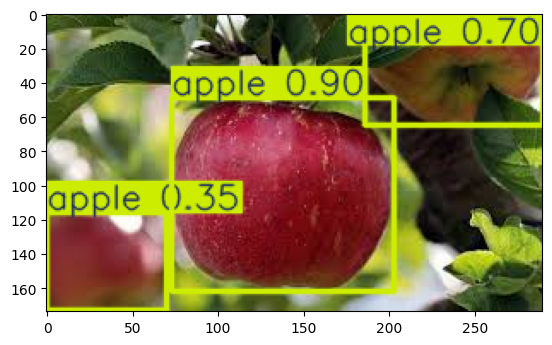

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# YOLO 모델로 객체 탐지
results = model("image copy 3.png")

# 탐지된 객체 개수 출력
num_objects = len(results[0].boxes)
print(f"탐지된 객체 개수: {num_objects}")

# 결과 이미지 가져오기
img = results[0].plot()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



plt.imshow(img_rgb)
plt.show()



In [4]:
# YOLO 모델 실행 결과 가져오기
results = model("image.png")

# 탐지된 객체의 클래스 인덱스 가져오기
class_ids = results[0].boxes.cls.cpu().numpy()  # Tensor를 NumPy 배열로 변환

# 클래스별 개수 세기
unique, counts = np.unique(class_ids, return_counts=True)
class_counts = dict(zip(unique, counts))

# 클래스 이름 매핑 (data.yaml의 nc=5 기준)
class_names = results[0].names  # YOLO 모델에서 클래스 이름 가져오기

# 클래스별 개수 출력
print(f"탐지된 객체 총 개수: {len(results[0])}개")
for class_id, count in class_counts.items():
    class_name = class_names[int(class_id)]
    print(f"{class_name}: {count}개")



image 1/1 /Users/songbeom/final-project/farm-web-python/analysis/notebooks/appleAi/image.png: 480x640 9 apples, 96.1ms
Speed: 1.0ms preprocess, 96.1ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
탐지된 객체 총 개수: 9개
apple: 9개



0: 640x640 1 100-_ripeness, 44.0ms
Speed: 1.5ms preprocess, 44.0ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Detected 1 fruits
Bounding Box (24, 49, 191, 207) - Dominant Colors (RGB): [[196 188 234]
 [ 48  38 182]
 [119 117 201]
 [ 47  87  45]
 [ 23  15 117]]
Cluster 0: RGB (196, 188, 234) - HEX #c4bcea
Cluster 1: RGB (48, 38, 182) - HEX #3026b6
Cluster 2: RGB (119, 117, 201) - HEX #7775c9
Cluster 3: RGB (47, 87, 45) - HEX #2f572d
Cluster 4: RGB (23, 15, 117) - HEX #170f75


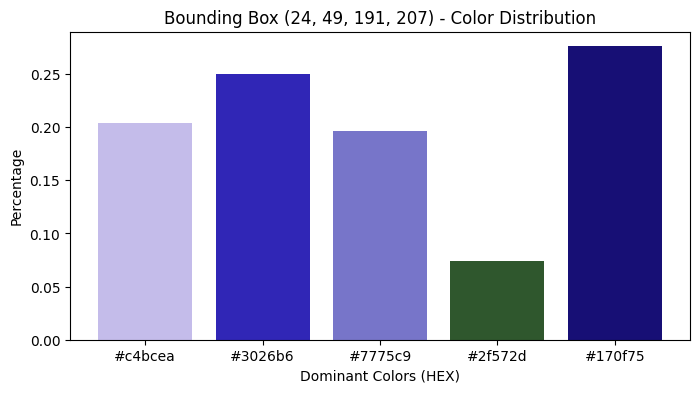

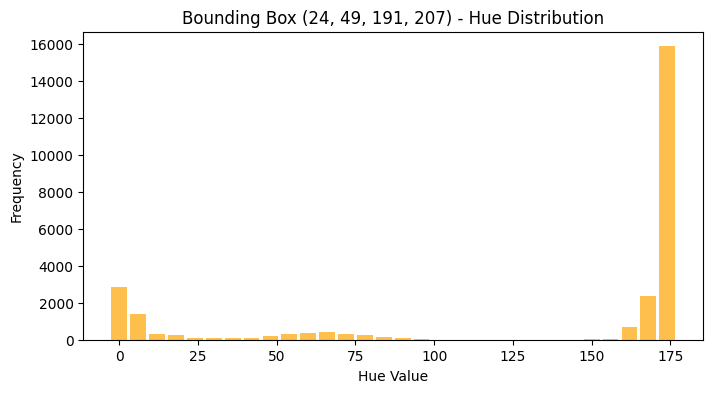

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.cluster import KMeans

# YOLO 모델 로드
model = YOLO("best.pt")  # 사전 학습된 YOLO 모델 사용

# 이미지 로드
image_path = "apple_test.jpg"  # 과일 이미지
image = cv2.imread(image_path)

# YOLO를 이용한 과일 객체 감지
results = model(image)
bounding_boxes = [tuple(map(int, box)) for result in results for box in result.boxes.xyxy]

print(f"Detected {len(bounding_boxes)} fruits")

# K-means를 이용한 대표 색상 추출 함수
def get_kmeans_colors(image, bbox, k=5):
    x1, y1, x2, y2 = bbox
    cropped = image[y1:y2, x1:x2]  # 바운딩 박스 크롭
    pixels = cropped.reshape(-1, 3)

    # K-means 클러스터링 수행 (결과 안정성을 위해 random_state 추가)
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(pixels)

    # 대표 색상 및 비율 계산
    unique, counts = np.unique(kmeans.labels_, return_counts=True)
    color_distribution = dict(zip(unique, counts / counts.sum()))  # 비율 계산
    dominant_colors = kmeans.cluster_centers_.astype(int)  # 대표 색상

    return dominant_colors, color_distribution

# RGB 값을 HEX 코드로 변환하는 함수
def rgb_to_hex(color):
    return "#{:02x}{:02x}{:02x}".format(color[0], color[1], color[2])

# 색상 분포 시각화 (K-means 기반)
def plot_kmeans_colors(dominant_colors, color_distribution, bbox):
    plt.figure(figsize=(8, 4))

    # RGB → HEX 변환
    hex_colors = [rgb_to_hex(color) for color in dominant_colors]

    # RGB 값을 (0~1) 범위로 변환 (Matplotlib에서 요구하는 포맷)
    normalized_colors = [tuple(c/255.0 for c in color) for color in dominant_colors]

    # 바 차트 시각화 (HEX 코드 라벨 추가)
    plt.bar(hex_colors, color_distribution.values(), color=normalized_colors)

    plt.title(f"Bounding Box {bbox} - Color Distribution")
    plt.xlabel("Dominant Colors (HEX)")
    plt.ylabel("Percentage")

    # 색상 정보를 출력
    for i, color in enumerate(dominant_colors):
        print(f"Cluster {i}: RGB {tuple(color)} - HEX {hex_colors[i]}")

    plt.show()

# HSV 히스토그램 기반 색상 분석 함수
def get_color_histogram(image, bbox):
    x1, y1, x2, y2 = bbox
    cropped = image[y1:y2, x1:x2]  # 바운딩 박스 크롭
    hsv = cv2.cvtColor(cropped, cv2.COLOR_BGR2HSV)
    hue_values = hsv[:, :, 0].flatten()  # Hue 채널 값만 가져옴
    hist, bins = np.histogram(hue_values, bins=30, range=[0, 180])  # Hue 값 히스토그램
    return hist, bins

# 색상 분포 시각화 (HSV 히스토그램 기반)
def plot_hsv_histogram(hist, bins, bbox):
    plt.figure(figsize=(8, 4))
    plt.bar(bins[:-1], hist, width=5, color="orange", alpha=0.7)  # width 조정으로 가독성 개선
    plt.title(f"Bounding Box {bbox} - Hue Distribution")
    plt.xlabel("Hue Value")
    plt.ylabel("Frequency")
    plt.show()

# 🔥 바운딩 박스별 색상 분석 실행
for bbox in bounding_boxes:
    dominant_colors, color_distribution = get_kmeans_colors(image, bbox)
    hist, bins = get_color_histogram(image, bbox)
    print(f"Bounding Box {bbox} - Dominant Colors (RGB): {dominant_colors}")
    plot_kmeans_colors(dominant_colors, color_distribution, bbox)
    plot_hsv_histogram(hist, bins, bbox) 

In [7]:
import numpy as np
from PIL import Image
from ultralytics import YOLO

class YoloPreprocessor:
    def __init__(self):
        self.model = YOLO('yolov8m.pt')

    def yolo_detect(self, img, target_class_id=47):
        img_np = np.array(img) if isinstance(img, Image.Image) else img
        results = self.model.predict(img_np)

        extracted_obj = []
        for result in results:
            for box, cls in zip(result.boxes, result.boxes.cls):
                if int(cls) == target_class_id:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cropped_obj = img_np[y1:y2, x1:x2]
                    extracted_obj.append(cropped_obj)

        # 개수 세기
        count = len(extracted_obj)

        return result, extracted_obj, count

In [8]:
# 클래스 인스턴스 생성
yoloPreprocessor = YoloPreprocessor()

# 이미지 열기
from PIL import Image
img = Image.open('./apple_test.jpg')

# 객체 인식 수행
extracted_objs, results, count = yoloPreprocessor.yolo_detect(img, target_class_id=47)

print(f"Detected {count} apples")




0: 640x640 1 person, 1 apple, 118.9ms
Speed: 1.0ms preprocess, 118.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Detected 1 apples


In [9]:
import numpy as np
from PIL import Image
from ultralytics import YOLO
import cv2

class AppleAnalyzer:
    def __init__(self, model_path='yolov8m.pt', target_class_id=47):
        self.model = YOLO(model_path)
        self.target_class_id = target_class_id

    def analyze(self, img):
        img_np = np.array(img) if isinstance(img, Image.Image) else img
        results = self.model.predict(img_np)

        detected = []

        for result in results:
            for box, cls in zip(result.boxes, result.boxes.cls):
                if int(cls) == self.target_class_id:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cropped = img_np[y1:y2, x1:x2]

                    # 색상 분석
                    color_ratio = self.analyze_color_ratio(cropped)

                    # 숙성도 추정
                    ripeness = self.estimate_ripeness(color_ratio)

                    detected.append({
                        "bbox": [x1, y1, x2, y2],
                        "color_ratio": color_ratio,
                        "ripeness": ripeness,
                        "cropped_img": cropped
                    })

        return {
            "count": len(detected),
            "detected_apples": detected,
            "results": results
        }

    def analyze_color_ratio(self, cropped_img):
        bgr = cv2.cvtColor(cropped_img, cv2.COLOR_RGB2BGR)
        hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

        red_lower1 = np.array([0, 70, 50])
        red_upper1 = np.array([10, 255, 255])
        red_lower2 = np.array([160, 70, 50])
        red_upper2 = np.array([179, 255, 255])
        green_lower = np.array([35, 40, 40])
        green_upper = np.array([85, 255, 255])
        brown_lower = np.array([10, 50, 20])
        brown_upper = np.array([25, 255, 200])

        red_mask1 = cv2.inRange(hsv, red_lower1, red_upper1)
        red_mask2 = cv2.inRange(hsv, red_lower2, red_upper2)
        red_mask = cv2.bitwise_or(red_mask1, red_mask2)
        green_mask = cv2.inRange(hsv, green_lower, green_upper)
        brown_mask = cv2.inRange(hsv, brown_lower, brown_upper)

        total_pixels = hsv.shape[0] * hsv.shape[1]
        red_ratio = round((cv2.countNonZero(red_mask) / total_pixels) * 100, 1)
        green_ratio = round((cv2.countNonZero(green_mask) / total_pixels) * 100, 1)
        brown_ratio = round((cv2.countNonZero(brown_mask) / total_pixels) * 100, 1)

        return {
            "빨강": red_ratio,
            "초록": green_ratio,
            "갈색": brown_ratio
        }

    def estimate_ripeness(self, color_ratio):
        ripeness_score = color_ratio["빨강"] / 100
        return round(ripeness_score, 2)

In [11]:
from PIL import Image

analyzer = AppleAnalyzer(model_path="yolov8m.pt")
img = Image.open("./apple_test.jpg")

result = analyzer.analyze(img)

print("총 감지된 사과:", result["count"])
for idx, apple in enumerate(result["detected_apples"]):
    print(f"\n🍎 사과 #{idx + 1}")
    print("색상 비율:", apple["color_ratio"])
    print("숙성도:", f"{int(apple['ripeness'] * 100)}%")


0: 640x640 1 person, 1 apple, 111.0ms
Speed: 1.3ms preprocess, 111.0ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
총 감지된 사과: 1

🍎 사과 #1
색상 비율: {'빨강': 74.3, '초록': 6.4, '갈색': 2.0}
숙성도: 74%



image 1/1 /Users/songbeom/final-project/farm-web-python/analysis/notebooks/appleAi/apple_test.jpg: 640x640 1 person, 1 apple, 106.0ms
Speed: 1.3ms preprocess, 106.0ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
탐지된 객체 개수: 2


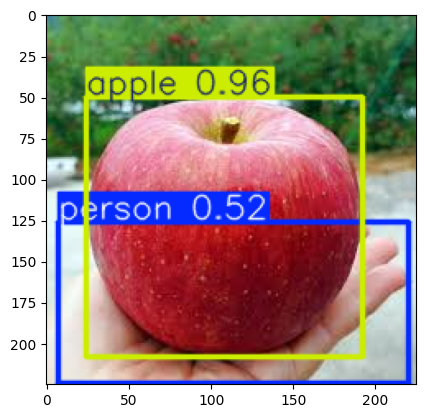

In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# YOLO 모델로 객체 탐지
results = model("apple_test.jpg")

# 탐지된 객체 개수 출력
num_objects = len(results[0].boxes)
print(f"탐지된 객체 개수: {num_objects}")

# 결과 이미지 가져오기
img = results[0].plot()
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()
